# Exploratory Data Analysis (EDA Awal)

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json, os

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_colwidth', 100)

df = pd.read_parquet('../data/raw/raw_comments_kopdes.parquet')
audit = json.load(open('../reports/data_quality_audit_summary.json'))

os.makedirs('../reports/figures', exist_ok=True)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (220051, 8)


,video_id,comment_id,parent_comment_id,level,username,nickname,comment,create_time
0,7526458489577737488,7643302845156410130,NaN,0.0,jbm123jayabetonmandiri,Christian sudartio,Beliau bilang untung nya 2 m ?,2026-05-24 10:58:57
1,7526458489577737488,7643361778294866706,7.643303e+18,1.0,sahrulmustakimm,sahrul,Makasih Mas,2026-05-24 14:47:33
2,7526458489577737488,7643368472755487495,7.643303e+18,1.0,jbm123jayabetonmandiri,Christian sudartio,Gimana untung nya 2 m..barang yg di jual ajh ga ada 1 m 😁,2026-05-24 15:13:29


## Ringkasan Jumlah Data

In [22]:
summary_counts = {
    'Total baris raw': len(df),
    'Baris unik (setelah dedup video_id+comment_id)': len(df) - audit['n_duplicate_scraper_rows'],
    'Video sumber unik': df['video_id'].nunique(),
    'Akun (username) unik': df['username'].nunique(),
}
for k, v in summary_counts.items():
    print(f'{k:55s}: {v:,}')

Total baris raw                                        : 220,051
Baris unik (setelah dedup video_id+comment_id)         : 127,139
Video sumber unik                                      : 27
Akun (username) unik                                   : 102,899


## Visualisasi Missing Value

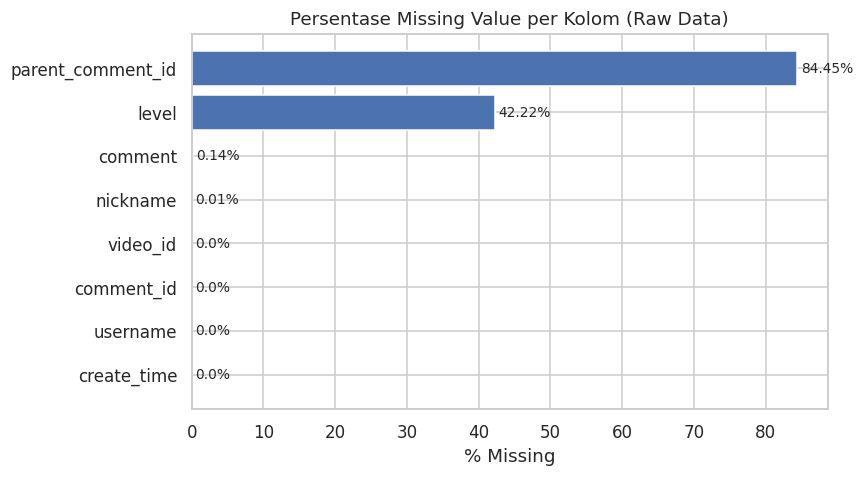

In [23]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(missing.index[::-1], missing_pct[::-1], color='#4C72B0')
ax.set_xlabel('% Missing')
ax.set_title('Persentase Missing Value per Kolom (Raw Data)')
for bar, val in zip(bars, missing_pct[::-1]):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2, f'{val}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../reports/figures/01_missing_values.png', bbox_inches='tight')
plt.show()

## Visualisasi Duplikasi Data

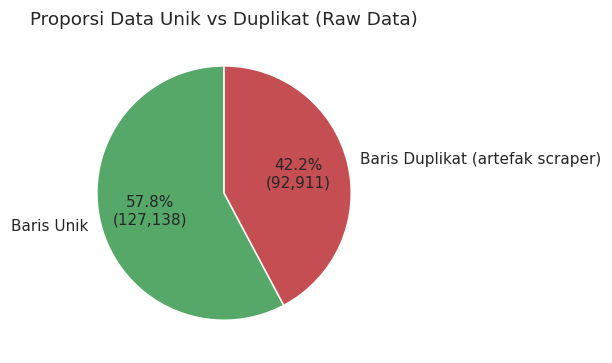

In [24]:
dup_data = pd.Series({
    'Baris Unik': len(df) - audit['n_duplicate_scraper_rows'],
    'Baris Duplikat (artefak scraper)': audit['n_duplicate_scraper_rows'],
})

fig, ax = plt.subplots(figsize=(5.5, 5.5))
colors = ['#55A868', '#C44E52']
wedges, texts, autotexts = ax.pie(
    dup_data, labels=dup_data.index, autopct=lambda p: f'{p:.1f}%\n({int(p/100*dup_data.sum()):,})',
    colors=colors, startangle=90, textprops={'fontsize': 10}
)
ax.set_title('Proporsi Data Unik vs Duplikat (Raw Data)')
plt.tight_layout()
plt.savefig('../reports/figures/02_duplicate_proportion.png', bbox_inches='tight')
plt.show()

## Distribusi Data per Video (Top 15)

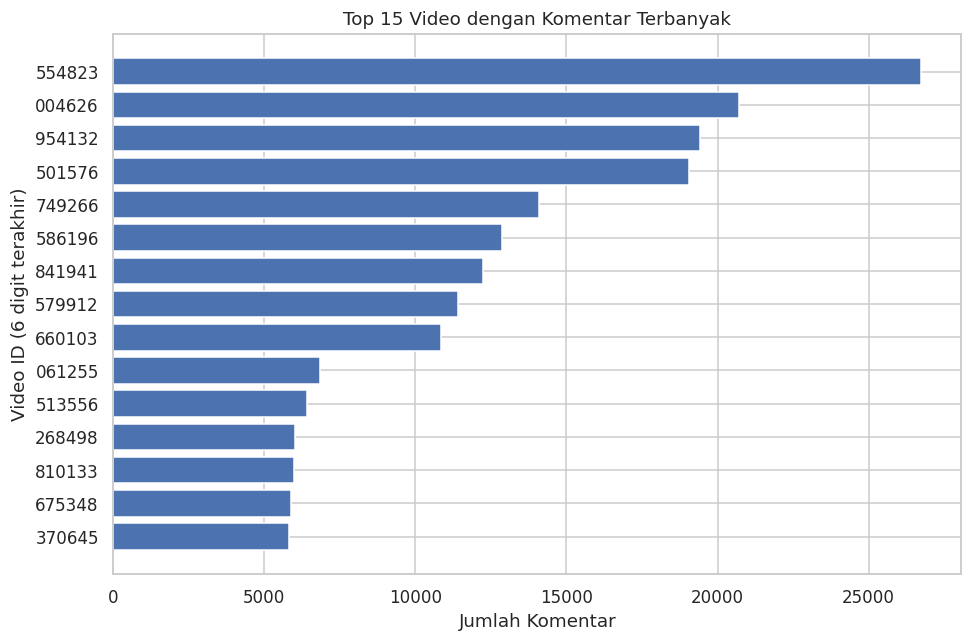

Video dengan komentar terbanyak menyumbang 26,737 komentar (12.2% dari total data).
5 video teratas menyumbang 100,051 komentar (45.5% dari total data).


In [25]:
video_counts = df['video_id'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh([str(v)[-6:] for v in video_counts.index[::-1]], video_counts.values[::-1], color='#4C72B0')
ax.set_xlabel('Jumlah Komentar')
ax.set_ylabel('Video ID (6 digit terakhir)')
ax.set_title('Top 15 Video dengan Komentar Terbanyak')
plt.tight_layout()
plt.savefig('../reports/figures/03_top_videos.png', bbox_inches='tight')
plt.show()

print(f"Video dengan komentar terbanyak menyumbang {video_counts.iloc[0]:,} komentar "
      f"({video_counts.iloc[0]/len(df)*100:.1f}% dari total data).")
print(f"5 video teratas menyumbang {video_counts.head(5).sum():,} komentar "
      f"({video_counts.head(5).sum()/len(df)*100:.1f}% dari total data).")

## Pola Temporal Volume Komentar dari Waktu ke Waktu

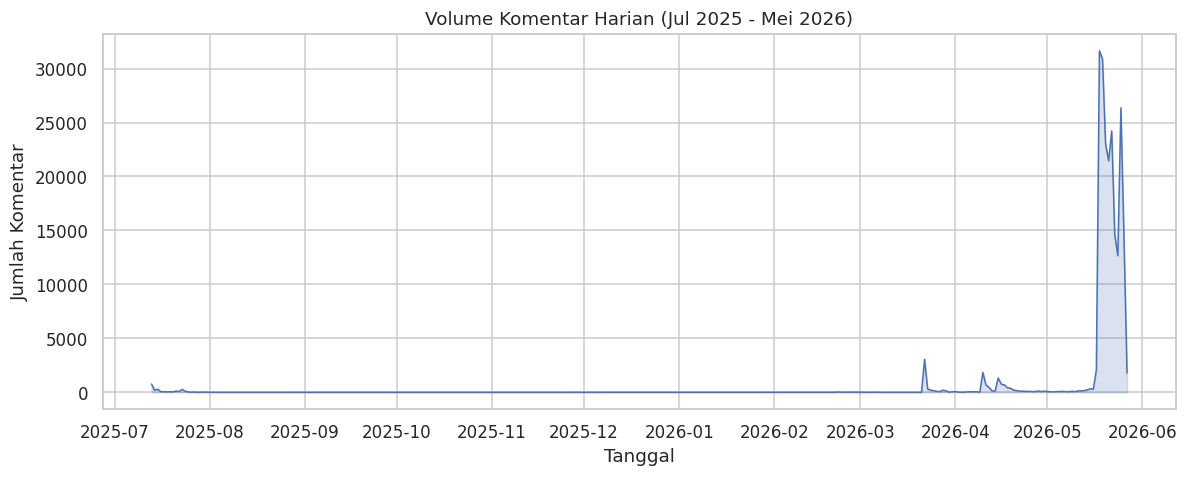

5 hari dengan volume komentar tertinggi (kemungkinan berkaitan momen viral/berita):
create_time
2026-05-18    31642
2026-05-19    30894
2026-05-25    26361
2026-05-22    24218
2026-05-20    23027
dtype: int64


In [26]:
daily = df.set_index('create_time').resample('D').size()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(daily.index, daily.values, color='#4C72B0', linewidth=1)
ax.fill_between(daily.index, daily.values, color='#4C72B0', alpha=0.2)
ax.set_title('Volume Komentar Harian (Jul 2025 - Mei 2026)')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Jumlah Komentar')
plt.tight_layout()
plt.savefig('../reports/figures/04_daily_volume.png', bbox_inches='tight')
plt.show()

top_days = daily.sort_values(ascending=False).head(5)
print('5 hari dengan volume komentar tertinggi (kemungkinan berkaitan momen viral/berita):')
print(top_days)

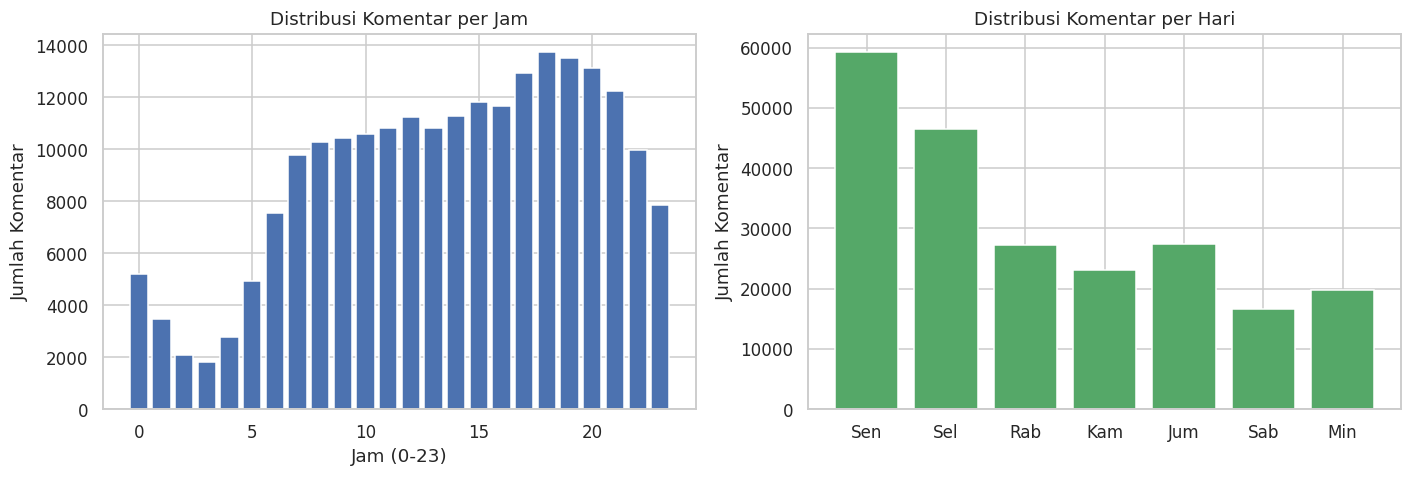

In [27]:
df['hour'] = df['create_time'].dt.hour
df['day_of_week'] = df['create_time'].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

hourly = df.groupby('hour').size()
axes[0].bar(hourly.index, hourly.values, color='#4C72B0')
axes[0].set_title('Distribusi Komentar per Jam')
axes[0].set_xlabel('Jam (0-23)')
axes[0].set_ylabel('Jumlah Komentar')

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df.groupby('day_of_week').size().reindex(dow_order)
axes[1].bar(range(7), dow.values, color='#55A868')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['Sen','Sel','Rab','Kam','Jum','Sab','Min'])
axes[1].set_title('Distribusi Komentar per Hari')
axes[1].set_ylabel('Jumlah Komentar')

plt.tight_layout()
plt.savefig('../reports/figures/05_activity_pattern.png', bbox_inches='tight')
plt.show()

## Distribusi Panjang Komentar

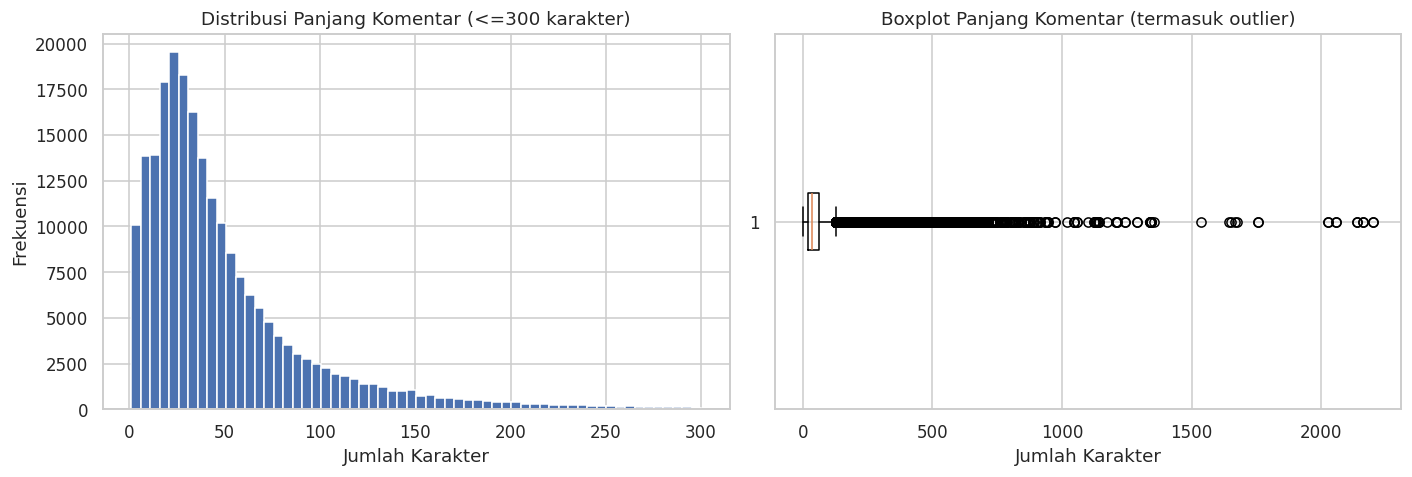

count    219746.000000
mean         52.709328
std          61.956748
min           1.000000
25%          20.000000
50%          35.000000
75%          63.000000
max        2200.000000
Name: comment, dtype: float64


In [28]:
comment_len = df['comment'].dropna().astype(object).str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(comment_len[comment_len <= 300], bins=60, color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribusi Panjang Komentar (<=300 karakter)')
axes[0].set_xlabel('Jumlah Karakter')
axes[0].set_ylabel('Frekuensi')

axes[1].boxplot(comment_len, vert=False, showfliers=True)
axes[1].set_title('Boxplot Panjang Komentar (termasuk outlier)')
axes[1].set_xlabel('Jumlah Karakter')

plt.tight_layout()
plt.savefig('../reports/figures/06_comment_length.png', bbox_inches='tight')
plt.show()

print(comment_len.describe())

## Struktur Percakapan: Top-Level vs Reply vs Duplikat Artefak

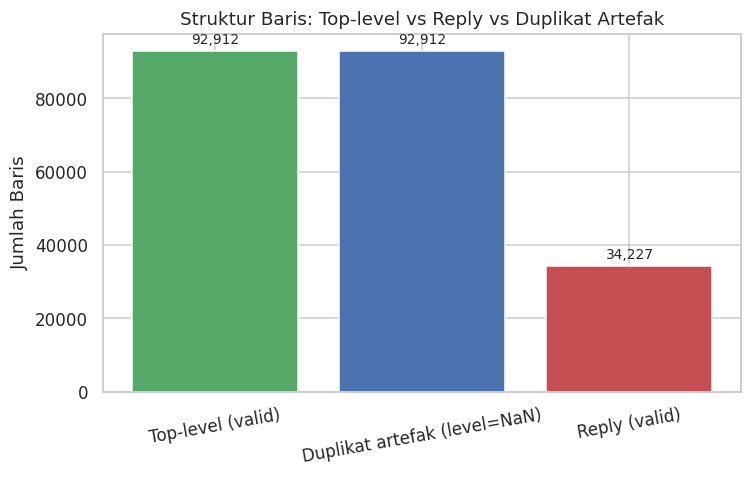

In [29]:
def classify_level(row):
    if row['level'] == 0.0:
        return 'Top-level (valid)'
    elif row['level'] == 1.0:
        return 'Reply (valid)'
    else:
        return 'Duplikat artefak (level=NaN)'

df['level_class'] = df.apply(classify_level, axis=1)
level_dist = df['level_class'].value_counts()

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ['#55A868', '#4C72B0', '#C44E52']
ax.bar(level_dist.index, level_dist.values, color=colors)
ax.set_title('Struktur Baris: Top-level vs Reply vs Duplikat Artefak')
ax.set_ylabel('Jumlah Baris')
for i, v in enumerate(level_dist.values):
    ax.text(i, v + 2000, f'{v:,}', ha='center', fontsize=9)
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig('../reports/figures/07_level_structure.png', bbox_inches='tight')
plt.show()

## Kesimpulan EDA Awal

1. **Volume data besar** (220.051 baris, 27 video) tetapi **42% adalah duplikat artefak
   scraper** — visualisasi pie chart mengonfirmasi temuan audit di notebook 02.
2. **Distribusi antar-video tidak merata** — 5 video teratas menyumbang porsi signifikan dari
   total komentar, penting diperhatikan agar model tidak bias ke topik spesifik salah satu video.
3. **Pola temporal** menunjukkan lonjakan volume komentar pada tanggal tertentu, konsisten
   dengan momen video-video tersebut viral/trending — bukti data riil, bukan sintetis.
4. **Pola aktivitas harian** menunjukkan jam-jam sibuk pengguna TikTok Indonesia (biasanya malam
   hari) — sesuai perilaku pengguna riil.
5. **Distribusi panjang komentar** right-skewed (median ~35 karakter, mayoritas komentar pendek
   khas media sosial), dengan sejumlah outlier panjang (>500 karakter) yang perlu diperiksa saat
   cleaning.
6. **Struktur level** mengonfirmasi 3 kelompok baris: top-level valid, reply valid, dan duplikat
   artefak — memperkuat rencana deduplikasi di Tahap 4.